In [3]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from datasets import load_dataset
from collections import Counter
import re
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Hyperparameters
VOCAB_SIZE = 10000
EMBED_DIM = 100
HIDDEN_DIM = 128
NUM_LAYERS = 1
BATCH_SIZE = 64
LR = 0.001
EPOCHS = 10
MAX_LEN = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device՝ {device}")

C:\Users\srbuh\PycharmProjects\nlp_course_2026_2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device՝ cuda


In [4]:
print("Downloading IMDB data from  HuggingFace...")
imdb = load_dataset("imdb")
train_data = imdb['train']
test_data = imdb['test']

print(f" {len(train_data)} train and {len(test_data)} test text:\n")
print("[Example] raw text from database:")
print("Text:", train_data[0]['text'][:200], "...")
print("Label:", train_data[0]['label'], "(0 = Negative, 1 = Positive)")

C:\Users\srbuh\PycharmProjects\nlp_course_2026_2\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\srbuh\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 290043.66 examples/s]


 25000 train and 25000 test text:

[Example] raw text from database:
Text: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev ...
Label: 0 (0 = Negative, 1 = Positive)


In [5]:
def tokenize(text):
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text.lower().split()

print("Vocabulary...")
word_counts = Counter()
for item in train_data:
    word_counts.update(tokenize(item['text']))

most_common_words = word_counts.most_common(VOCAB_SIZE - 2)
word2idx = {"<pad>": 0, "<unk>": 1}
for idx, (word, _) in enumerate(most_common_words, start=2):
    word2idx[word] = idx

print(f"Vocab size: {len(word2idx)} word ")
print("[Example] Most frequent words and their indexes:")
print(list(word2idx.items())[:10])

Vocabulary...
Vocab size: 10000 word 
[Example] Most frequent words and their indexes:
[('<pad>', 0), ('<unk>', 1), ('the', 2), ('and', 3), ('a', 4), ('of', 5), ('to', 6), ('is', 7), ('in', 8), ('it', 9)]


In [6]:
def encode_and_pad(dataset):
    sequences, labels = [], []
    for item in dataset:
        words = tokenize(item['text'])
        seq = [word2idx.get(w, 1) for w in words]

        # Padding / Truncating
        if len(seq) > MAX_LEN:
            seq = seq[:MAX_LEN]
        else:
            seq = [0] * (MAX_LEN - len(seq)) + seq

        sequences.append(seq)
        labels.append(item['label'])

    return torch.tensor(sequences, dtype=torch.long), torch.tensor(labels, dtype=torch.float32)

print("Data -> Tensor...")
X_train, y_train = encode_and_pad(train_data)
X_test, y_test = encode_and_pad(test_data)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print(f"Len of train (X_train) tensor: {X_train.shape} -> (Batch Size, Sequence Length)")
print("[EXAMPLE] :")
print(X_train[0][-20:].numpy())

Data -> Tensor...
Len of train (X_train) tensor: torch.Size([25000, 256]) -> (Batch Size, Sequence Length)
[EXAMPLE] :
[ 238   70   40    6 1471   81    3   96  270    6   26  596    8 8166
 2136    8  917   10  236    1]


In [7]:
class SentimentModel(nn.Module):
    def __init__(self, model_type, vocab_size, embed_dim, hidden_dim, num_layers):
        super(SentimentModel, self).__init__()
        self.model_type = model_type
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        if model_type == 'RNN':
            self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers, batch_first=True)
        elif model_type == 'LSTM':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        elif model_type == 'GRU':
            self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers, batch_first=True)

        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, debug=False):
        if debug: print(f"Input: {x.shape} -> [Batch, Sequence Length]")

        embeds = self.embedding(x)
        if debug: print(f"After Embedding layer: {embeds.shape} -> [Batch, Seq Len, Embedding Dim]")

        if self.model_type == 'LSTM':
            out, _ = self.rnn(embeds)
        else:
            out, _ = self.rnn(embeds)

        if debug: print(f"{self.model_type} : {out.shape} -> [Batch, Seq Len, Hidden Dim]")

        out = out[:, -1, :]
        if debug: print(f": {out.shape} -> [Batch, Hidden Dim]")

        out = self.fc(out)
        out = self.sigmoid(out)
        if debug: print(f"After Linear+Sigmoid : {out.squeeze(-1).shape} -> [Batch]\n")

        return out.squeeze(-1)

dummy_model = SentimentModel('RNN', VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS).to(device)
dummy_batch_x, _ = next(iter(train_loader))

_ = dummy_model(dummy_batch_x.to(device), debug=True)

Input: torch.Size([64, 256]) -> [Batch, Sequence Length]
After Embedding layer: torch.Size([64, 256, 100]) -> [Batch, Seq Len, Embedding Dim]
RNN : torch.Size([64, 256, 128]) -> [Batch, Seq Len, Hidden Dim]
: torch.Size([64, 128]) -> [Batch, Hidden Dim]
After Linear+Sigmoid : torch.Size([64]) -> [Batch]



In [13]:
def train_model(model, train_loader, epochs, lr):
    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    print(f"\n[{model.model_type}] TRAINING...")
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"  Epoch {epoch+1}/{epochs} | Average Loss: {total_loss/len(train_loader):.4f}")
    return model

def evaluate_model(model, test_loader):
    print(f"[{model.model_type}] EVALUATION ...")
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = (outputs >= 0.5).int().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"\n>>> {model.model_type} Results <<<")
    print(f"Accuracy:  {acc:.4f} \nPrecision: {prec:.4f} \nRecall:    {rec:.4f} \nF1-Score:  {f1:.4f}")

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    plt.title(f'{model.model_type} Confusion Matrix')
    plt.ylabel('Real label')
    plt.xlabel('Predicted label')
    plt.show()


[RNN] TRAINING...
  Epoch 1/10 | Average Loss: 0.6728
  Epoch 2/10 | Average Loss: 0.6520
  Epoch 3/10 | Average Loss: 0.6428
  Epoch 4/10 | Average Loss: 0.5811
  Epoch 5/10 | Average Loss: 0.5675
  Epoch 6/10 | Average Loss: 0.5185
  Epoch 7/10 | Average Loss: 0.5933
  Epoch 8/10 | Average Loss: 0.5159
  Epoch 9/10 | Average Loss: 0.5669
  Epoch 10/10 | Average Loss: 0.5036
[RNN] EVALUATION ...

>>> RNN Results <<<
Accuracy:  0.6698 
Precision: 0.6296 
Recall:    0.8250 
F1-Score:  0.7142


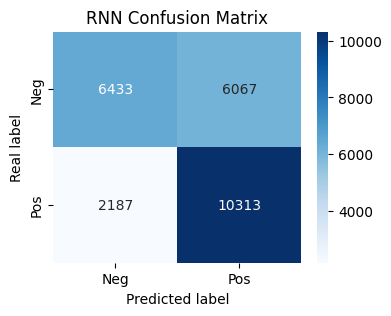

In [10]:
rnn_model = SentimentModel('RNN', VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
train_model(rnn_model, train_loader, EPOCHS, LR)
evaluate_model(rnn_model, test_loader)


[LSTM] TRAINING...
  Epoch 1/10 | Average Loss: 0.6346
  Epoch 2/10 | Average Loss: 0.5523
  Epoch 3/10 | Average Loss: 0.4275
  Epoch 4/10 | Average Loss: 0.4875
  Epoch 5/10 | Average Loss: 0.4344
  Epoch 6/10 | Average Loss: 0.3360
  Epoch 7/10 | Average Loss: 0.2800
  Epoch 8/10 | Average Loss: 0.2323
  Epoch 9/10 | Average Loss: 0.2115
  Epoch 10/10 | Average Loss: 0.1750
[LSTM] EVALUATION ...

>>> LSTM Results <<<
Accuracy:  0.8425 
Precision: 0.8296 
Recall:    0.8621 
F1-Score:  0.8455


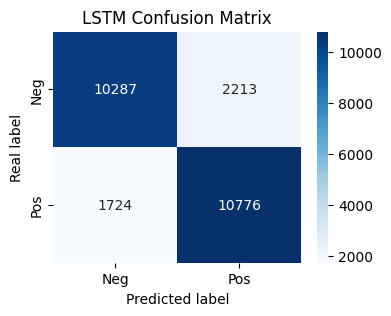

In [11]:
lstm_model = SentimentModel('LSTM', VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
train_model(lstm_model, train_loader, EPOCHS, LR)
evaluate_model(lstm_model, test_loader)


[GRU] TRAINING...
  Epoch 1/10 | Average Loss: 0.6143
  Epoch 2/10 | Average Loss: 0.5530
  Epoch 3/10 | Average Loss: 0.4371
  Epoch 4/10 | Average Loss: 0.3681
  Epoch 5/10 | Average Loss: 0.2535
  Epoch 6/10 | Average Loss: 0.1982
  Epoch 7/10 | Average Loss: 0.1513
  Epoch 8/10 | Average Loss: 0.1140
  Epoch 9/10 | Average Loss: 0.0760
  Epoch 10/10 | Average Loss: 0.0500
[GRU] EVALUATION ...

>>> GRU Results <<<
Accuracy:  0.8590 
Precision: 0.8603 
Recall:    0.8573 
F1-Score:  0.8588


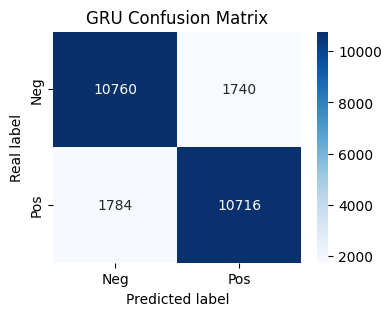

In [12]:
gru_model = SentimentModel('GRU', VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
train_model(gru_model, train_loader, EPOCHS, LR)
evaluate_model(gru_model, test_loader)